Dataset Loaded Successfully
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
First 5 rows:
+----------+----+------+------+---+------+----+
|total_bill| tip|   sex|smoker|day|  time|size|
+----------+----+------+------+---+------+----+
|     16.99|1.01|Female|    No|Sun|Dinner|   2|
|     10.34|1.66|  Male|    No|Sun|Dinner|   3|
|     21.01| 3.5|  Male|    No|Sun|Dinner|   3|
|     23.68|3.31|  Male|    No|Sun|Dinner|   2|
|     24.59|3.61|Female|    No|Sun|Dinner|   4|
+----------+----+------+------+---+------+----+
only showing top 5 rows
Dataset Structure:
root
 |-- total_bill: double (nullable = true)
 |-- tip: double (nullable = true)
 |-- sex: string (nullable = true)
 |-- smoker: string (nullable = true)
 |--

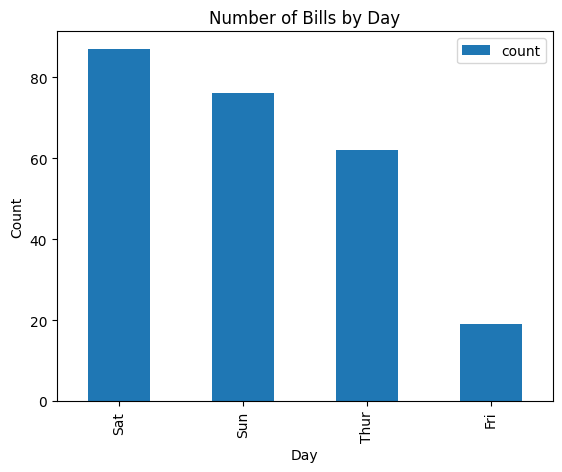

In [12]:
# STEP 1: Install PySpark
!pip install pyspark

# STEP 2: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

# STEP 3: Download Dataset (Working Link)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

# Save dataset locally
df.to_csv("sales_data.csv", index=False)

print("Dataset Loaded Successfully")
print(df.head())

# STEP 4: Create Spark Session
spark = SparkSession.builder.appName("BigDataAnalysis").getOrCreate()

# STEP 5: Load Dataset using PySpark
data = spark.read.csv("sales_data.csv", header=True, inferSchema=True)

# STEP 6: Show Dataset
print("First 5 rows:")
data.show(5)

# STEP 7: Dataset Schema
print("Dataset Structure:")
data.printSchema()

# STEP 8: Total Records
print("Total Rows:", data.count())

# STEP 9: Group Analysis
print("Bills by Day:")
day_analysis = data.groupBy("day").count().orderBy("count", ascending=False)
day_analysis.show()

# STEP 10: Average Bill by Day
from pyspark.sql.functions import avg

avg_bill = data.groupBy("day").agg(avg("total_bill"))
avg_bill.show()

# STEP 11: Visualization
day_df = day_analysis.toPandas()

day_df.plot(kind="bar", x="day", y="count")

plt.title("Number of Bills by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

# STEP 12: Stop Spark
spark.stop()

In [13]:
Big Data Analysis using PySpark

Name: Mahesh Mavunuri
Internship: CODTECH
Task: Task-1 Big Data Analysis
Technologies Used: Python, PySpark, Pandas, Matplotlib

---

Objective

The objective of this task is to perform Big Data Analysis using PySpark. The dataset is analyzed to understand customer billing patterns in a restaurant. Using PySpark operations like grouping and aggregation, we extract insights from the dataset and visualize the results.

---

Dataset Description

The dataset contains restaurant bill records. It includes information about the total bill amount, tip given by the customer, gender, smoking status, day of visit, time of visit, and number of people at the table.

Total Records: 244
Total Columns: 7

Dataset Columns

- total_bill – Total bill amount
- tip – Tip given by the customer
- sex – Gender of the customer
- smoker – Whether the customer is a smoker or not
- day – Day of the visit
- time – Lunch or Dinner
- size – Number of people at the table

---

Tools and Technologies Used

- Python
- PySpark
- Pandas
- Matplotlib
- Jupyter Notebook / Google Colab

---

Data Analysis Results

Bills by Day

- Saturday has the highest number of bills with 87 records.
- Sunday has 76 bills.
- Thursday has 62 bills.
- Friday has the lowest number of bills with 19 bills.

This shows that weekends attract more customers compared to weekdays.

---

Average Bill Amount by Day

- Sunday: Average bill ≈ 21.41
- Saturday: Average bill ≈ 20.44
- Thursday: Average bill ≈ 17.68
- Friday: Average bill ≈ 17.15

This indicates that customers tend to spend more money during weekends.

---

Visualization

A bar chart was created to display the number of bills per day. The chart clearly shows that Saturday and Sunday have the highest customer activity, which confirms that weekends are the busiest days for the restaurant.

---

Conclusion

Using PySpark, we successfully analyzed the restaurant dataset and extracted meaningful insights. The analysis shows that weekends are the busiest days and customers tend to spend more during those days. This demonstrates how big data tools like PySpark can help businesses understand customer behavior and make better decisions.

SyntaxError: invalid character '–' (U+2013) (3392658440.py, line 25)